In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/H100/llama3.2-vision_11b-qwen2.5_32b"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.9994949494949495,
 'total_execution_time': 20963.857213000003,
 'mean_execution_time': 10.587806673232325,
 'total_tasks': 1980,
 'SUCCESS': 1979,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 1}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,full_logs,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 23:02:12.074140,2025-03-31 23:02:44.047301,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",31.9732,6,2322,1929,393,0.0,SUCCESS,31.973161,0 days 00:00:31
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 23:02:44.052890,2025-03-31 23:02:53.509545,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",9.4567,6,2333,1936,397,0.0,SUCCESS,9.456655,0 days 00:00:09
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 23:02:53.514423,2025-03-31 23:03:03.807537,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",10.2931,6,2334,1892,442,0.0,SUCCESS,10.293114,0 days 00:00:10
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 23:03:03.812259,2025-03-31 23:03:13.828284,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",10.0160,6,2356,1932,424,0.0,SUCCESS,10.016025,0 days 00:00:10
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 23:03:13.833355,2025-03-31 23:03:23.088630,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",9.2553,6,2362,1973,389,0.0,SUCCESS,9.255275,0 days 00:00:09


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

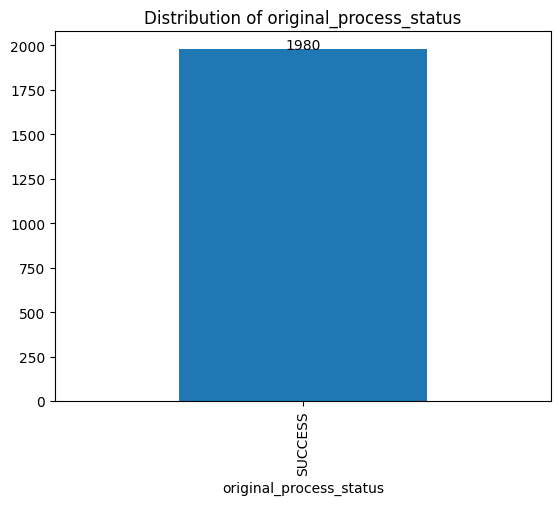

In [7]:
plot_value_distribution(df, "original_process_status")

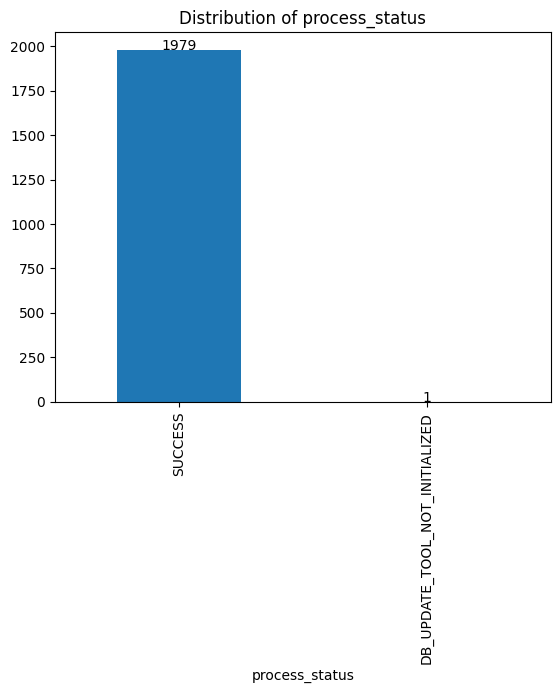

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: SUCCESS
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-03-31 23:02:12.074140
--------------------------------------------------
end_time: 2025-03-31 23:02:44.047301
-----------------------------------------

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

9

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-03-31T23:02:12.074140",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-03-31T23:02:35.505704",


In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\nSent by: Robin Levine\\nYou paid $196 to Tanya\\nTransaction Reference Number: EC4F9FE854344D25\\nTransaction Date: 04/23/23\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 139, \"prompt_tokens\": 90, \"completion_tokens\": 49, \"total_cost\": 0.0}}",
    "timestamp": "2025-03-31T23:02:35.505704",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC4F9FE854344D25\", \"amount\": \"$196.00\", \"rec

3

In [15]:
df["process_status"].value_counts()

process_status
SUCCESS                           1979
DB_UPDATE_TOOL_NOT_INITIALIZED       1
Name: count, dtype: int64

In [16]:
df_filtered = (
    df[df["process_status"] == "DB_UPDATE_TOOL_NOT_INITIALIZED"]
    .copy()
    .reset_index(drop=True)
)
len(df_filtered)

1

In [17]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: E-0C0048C0EAC14EB4ACFFFDFAF1580104
--------------------------------------------------
sender_email: DustinYang@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 1089582
--------------------------------------------------
email_body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1089582, related to our recent order with you. Here are the details:  
Invoice ID: 1089582
Invoice Date: 1/19/23
Total Amount paid: 76.0
Transaction Reference Number - T-2FC68DD3A03345D2
Thank you and I look forward to our continued business
Best regards,
Dustin Yang
--------------------------------------------------
attachments: 
--------------------------------------------------
process_status: DB_UPDATE_TOOL_NOT_IN

In [18]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

8

In [19]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: DustinYang@example.com\n            Subject: Payment Confirmation for Invoice ID: 1089582\n            Body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1089582, related to our recent order with you. Here are the details:  \nInvoice ID: 1089582\nInvoice Date: 1/19/23\nTotal Amount paid: 76.0\nTransaction Reference Number - T-2FC68DD3A03345D2\nThank you and I look forward to our continued business\nBest regards,\nDustin Yang\n            \n            \n                ",
    "timestamp": "2025-04-01T03:02:42.300250",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_to

In [20]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"1089582\", \"bank_name\": \"Bank 467\", \"transaction_id\": \"T-2FC68DD3A03345D2\", \"amount\": \"$76.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Dustin Yang\"}}",
    "timestamp": "2025-04-01T03:02:46.943465",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}


1

In [21]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'The invoice amount of $76.0 for Invoice ID: 1089582 matches the database record and the confirmation email from Dustin Yang.\n\nRequest to update the reconciliation status with the following details:\n- Sender: DustinYang@example.com  \n- Subject: Payment Confirmation for Invoice ID: 1089582\n- Body Summary: Confirms payment of $76.0 for Invoice ID: 1089582 dated 1/19/23 with transaction reference T-2FC68DD3A03345D2\n\nPlease proceed to update the status in the system accordingly.',
 'timestamp': '2025-04-01T03:02:54.985516',
 'usage': {'input_tokens': 867,
  'output_tokens': 136,
  'total_tokens': 1003,
  'input_token_details': {},
  'output_token_details': {}},
 'model_name': 'qwen2.5:32b',
 'additional_kwargs': {}}

In [25]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 1089582"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [26]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 1089582
--------------------------------------------------
bank_name: Bank 467
--------------------------------------------------
transaction_id: T-2FC68DD3A03345D2
--------------------------------------------------
amount: 76.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Dustin Yang
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [27]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1